# Amazon Delivery Time Analysis

# Project: Can Probability Predict Whether an Amazon Delivery Will Be Late?

In this project, we use historical Amazon delivery data to explore how **probability and distributions** can answer real-world delivery questions.  

Starting with **Probability Mass Functions (PMF), Probability Density Functions (PDF), and Cumulative Distribution Functions (CDF)**, we will analyze delivery times, investigate how factors such as traffic and weather affect delivery performance, and estimate the likelihood of a delivery taking longer than a given threshold.  

We will then connect these statistical insights to **conditional probability and machine learning**, showing how probability provides the foundation for predicting future delivery outcomes.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.integrate import quad
# from KDEpy import FFTKDE
from scipy.interpolate import interp1d  

import warnings
warnings.filterwarnings('ignore')

## Data Loading and Inspection

In [2]:
df = pd.read_csv("data/amazon_delivery.csv")
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [3]:
# Check missing values
df.isna().sum()

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

In [4]:
# Summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Agent_Age,43739.0,29.567137,5.815155,15.000000,25.000000,30.000000,35.000000,50.000000
Agent_Rating,43685.0,4.633780,0.334716,1.000000,4.500000,4.700000,4.900000,6.000000
Store_Latitude,43739.0,17.210960,7.764225,-30.902872,12.933298,18.551440,22.732225,30.914057
Store_Longitude,43739.0,70.661177,21.475005,-88.366217,73.170283,75.898497,78.045359,88.433452
Drop_Latitude,43739.0,17.459031,7.342950,0.010000,12.985996,18.633626,22.785049,31.054057
Drop_Longitude,43739.0,70.821842,21.153148,0.010000,73.280000,76.002574,78.104095,88.563452
Delivery_Time,43739.0,124.905645,51.915451,10.000000,90.000000,125.000000,160.000000,270.000000


In [5]:
# We only need Weather, Traffic, and Delivery_Time to be non-null for the
# analysis ahead.
analysis_columns = ["Weather", "Traffic", "Delivery_Time"]
df = df.dropna(subset=analysis_columns)
df.info()

<class 'pandas.DataFrame'>
Index: 43648 entries, 0 to 43738
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         43648 non-null  str    
 1   Agent_Age        43648 non-null  int64  
 2   Agent_Rating     43594 non-null  float64
 3   Store_Latitude   43648 non-null  float64
 4   Store_Longitude  43648 non-null  float64
 5   Drop_Latitude    43648 non-null  float64
 6   Drop_Longitude   43648 non-null  float64
 7   Order_Date       43648 non-null  str    
 8   Order_Time       43648 non-null  str    
 9   Pickup_Time      43648 non-null  str    
 10  Weather          43648 non-null  str    
 11  Traffic          43648 non-null  str    
 12  Vehicle          43648 non-null  str    
 13  Area             43648 non-null  str    
 14  Delivery_Time    43648 non-null  int64  
 15  Category         43648 non-null  str    
dtypes: float64(5), int64(2), str(9)
memory usage: 5.7 MB


In [6]:
df = df[['Weather', 'Traffic','Delivery_Time']]
df.head()

,Weather,Traffic,Delivery_Time
0,Sunny,High,120
1,Stormy,Jam,165
2,Sandstorms,Low,130
3,Sunny,Medium,105
4,Cloudy,High,150


## Probability Mass Function (PMF)

Before we can talk about delivery *time*, it helps to start with something simpler: a variable that can only take a small number of distinct values.

`Weather` and `Traffic` are both **discrete** - a delivery is recorded as "Sunny" or "Stormy", "High" or "Low", never something in between. For a discrete random variable, we can estimate its probability mass function (PMF) directly from observed frequencies:

P(X = x) = (number of deliveries where X = x) / (total number of deliveries)

This tells us the probability that a *randomly selected* delivery falls into each category - not a prediction about any single delivery.

In [7]:
# P.m.f of Weather
pmfWeather = ((df['Weather'].value_counts() / df['Weather']
    .value_counts().sum())
    .to_frame(name = "Probability (P(X=x))")
    .T.rename_axis("Weather (X)", axis=1))
pmfWeather

Weather (X),Fog,Stormy,Cloudy,Sandstorms,Windy,Sunny
Probability (P(X=x)),0.170455,0.168942,0.166972,0.165987,0.165483,0.162161


In [13]:
# P.m.f of Traffic
pmfTraffic = ((df['Traffic'].value_counts() / df['Traffic']
    .value_counts().sum())
    .to_frame(name = "Probability (P(X=x))")
    .T.rename_axis("Traffic (X)", axis=1))
pmfTraffic

Traffic (X),Low,Jam,Medium,High
Probability (P(X=x)),0.343635,0.314447,0.243493,0.098424


**What this tells us:** each table shows how delivery observations are distributed across categories of a single variable. For example, the PMF for `Traffic` tells us how likely a randomly chosen delivery is to have occurred under "Low", "Medium", "High", or "Jam" traffic conditions in this dataset.

A defining property of a PMF is that the probabilities of all possible outcomes must sum to exactly 1 - every delivery falls into exactly one category, so nothing is left over and nothing is double-counted. We check that below.

In [9]:
# Axiom of probabilities
print("Axioms of Probability: All probabilities sum upto one\n")
print(f"Sum of Weather Probabilities: {pmfWeather.sum(axis=1)} \n Sum of Traffic Probabilities: {pmfTraffic.sum(axis=1)}")

Axioms of Probability: All probabilities sum upto one

Sum of Weather Probabilities: Probability (P(X=x))    1.0
dtype: float64 
 Sum of Traffic Probabilities: Probability (P(X=x))    1.0
dtype: float64


## Probability Density Function (PDF)

`Delivery_Time` is different from `Weather` or `Traffic` - it's a **continuous** measurement (in this dataset, recorded in minutes). With a continuous variable, the probability of any *exact* value is essentially zero, so a PMF-style table doesn't make sense here.

Instead, we estimate a probability **density** function. A kernel density estimate (KDE) gives us a smooth curve approximating the underlying distribution of delivery times - but it's important to be precise about what this curve means:

- The **height** of the curve at a point is a density, not a probability.
- **Probability** corresponds to the **area under the curve** over some interval, e.g. P(120 < Delivery_Time < 140).
- The KDE is an *estimate* of the true underlying density, not the density itself.

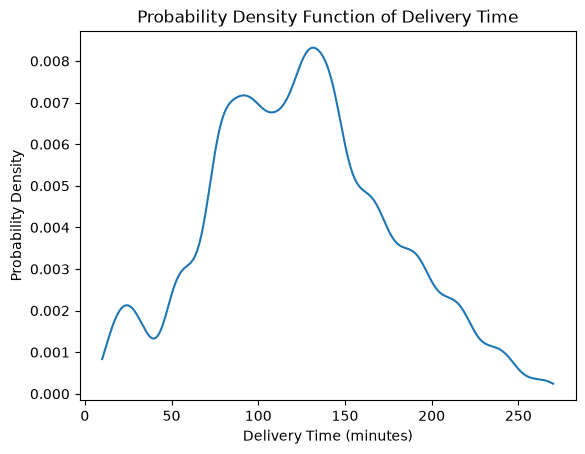

In [10]:
# Remove missing values
delivery_times = df["Delivery_Time"].dropna()

# Estimate the PDF
kde = gaussian_kde(delivery_times)

# Create x-values for the curve
x = np.linspace(
    delivery_times.min(),
    delivery_times.max(),
    500
)

# Get density values
y = kde(x)

# Plot the PDF
plt.plot(x, y)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Probability Density")
plt.title("Probability Density Function of Delivery Time")
plt.show()

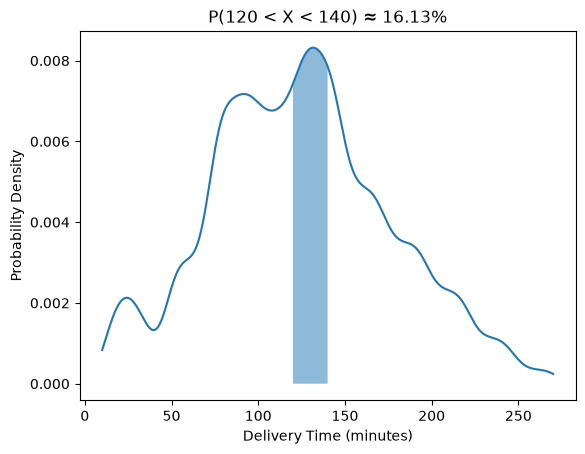

In [11]:
delivery_times = df["Delivery_Time"].dropna()

# Estimate PDF
kde = gaussian_kde(delivery_times)

# X values
x = np.linspace(delivery_times.min(), delivery_times.max(), 500)
y = kde(x)
upperBound = 140
lowerBound = 120

# Calculate probability
# Wrap it in a lambda so it only returns a single number (scalar)
probability, _ = quad(lambda val: kde(val)[0], lowerBound, upperBound)


# Plot PDF
plt.plot(x, y)

# Shade area between 30 and 45
x_fill = np.linspace(lowerBound, upperBound, 200)
y_fill = kde(x_fill)

plt.fill_between(x_fill, y_fill, alpha=0.5)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Probability Density")
plt.title(f"P({lowerBound} < X < {upperBound}) ≈ {probability:.2%}")

plt.show()

**What this tells us:** the shaded region shows the estimated probability that a randomly selected delivery takes between 120 and 140 minutes - computed as the area under the density curve over that interval, not as the height of the curve at any single point. This is the core distinction between a PMF and a PDF: a PMF gives probability directly at each discrete outcome, while a PDF only gives probability once you integrate over an interval.

In [12]:
#gausian kernel density

kde = gaussian_kde(delivery_times)

prob, error = quad(lambda val: kde(val)[0], delivery_times.min(), delivery_times.max())

print(f"Proability: {(prob * 100)}%")


Proability: 99.48437677716242%


In [ ]:
# 2. Extract discrete arrays from the library
x_grid, density = FFTKDE(kernel='epa', bw='silverman').fit(np.asarray(delivery_times)).evaluate(500)

# 3. CONVERT ARRAYS INTO A CONTINUOUS FUNCTION
# We use linear interpolation. 
# bounds_error=False and fill_value=0.0 ensure that if quad looks 
# outside the library's evaluated range, it safely gets a density of 0.
continuous_kde_func = interp1d(x_grid, density, kind='linear', 
                               bounds_error=False, fill_value=0.0)

# 4. Use quad to compute the continuous area under the curve
# Integrating from 0 to 10 (or -np.inf to np.inf)
raw_area, _ = quad(continuous_kde_func, x_grid.min(), x_grid.max())


print(f"Calculated Area via quad: {raw_area:.2f}")

## Cumulative Distribution Function (CDF)

The PDF told us about density in a narrow window. Often what we actually want to know is simpler: **what's the probability that delivery time is at most some value x?**

That's exactly what the cumulative distribution function (CDF) gives us:

F(x) = P(Delivery_Time ≤ x)

We'll compute the **empirical CDF** directly from the data - for any x, it's just the proportion of deliveries with a delivery time less than or equal to x. Unlike the PDF, we don't need to estimate anything here; the empirical CDF is just the data, sorted and accumulated.

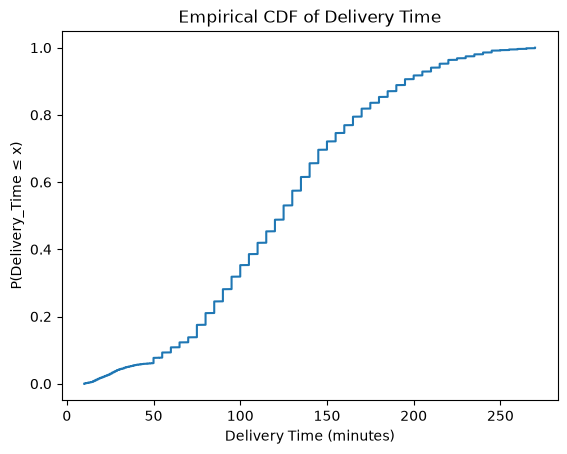

In [14]:
# Empirical CDF of delivery time
sorted_times = np.sort(df["Delivery_Time"])
cumulative_prob = np.arange(1, len(sorted_times) + 1) / len(sorted_times)

plt.plot(sorted_times, cumulative_prob)

plt.xlabel("Delivery Time (minutes)")
plt.ylabel("P(Delivery_Time ≤ x)")
plt.title("Empirical CDF of Delivery Time")
plt.show()

In [15]:
# Answer concrete questions using the empirical CDF
def empirical_cdf(x, data):
    return (data <= x).mean()

for threshold in [30, 45, 60]:
    prob = empirical_cdf(threshold, df["Delivery_Time"])
    print(f"P(Delivery_Time <= {threshold}) = {prob:.2%}")

prob_over_60 = 1 - empirical_cdf(60, df["Delivery_Time"])
print(f"P(Delivery_Time > 60) = {prob_over_60:.2%}")

P(Delivery_Time <= 30) = 4.24%
P(Delivery_Time <= 45) = 5.93%
P(Delivery_Time <= 60) = 10.81%
P(Delivery_Time > 60) = 89.19%


**What this tells us:** the CDF curve rises from 0 to 1 as delivery time increases - its height at any point x is the proportion of deliveries completed in x minutes or less. The steeper the curve, the more deliveries are concentrated around that range of times.

Note the numbers above are specific to this dataset - read them off the printed output rather than assuming round percentages. This also gives us a natural way to define what counts as a "late" delivery later on: we can choose a threshold and directly read off, from the data itself, what fraction of deliveries fall on each side of it.